# Projeto Final: Introdução à Ciência de Dados
**Professor:** Alexandre Roriz  
**Tema:** Análise Exploratória de Dados de Engajamento e Tendências no TikTok  

## Descrição do Dataset
Este conjunto de dados contém métricas detalhadas de vídeos que alcançaram o feed principal do TikTok, incluindo contagem de visualizações, curtidas, compartilhamentos, comentários, duração dos vídeos e as categorias de conteúdo. O objetivo é entender quais fatores influenciam o algoritmo de entrega da plataforma.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Configuração visual dos gráficos (Estilo Graphite/Clean)
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Criando a nossa própria Base de Dados (TikTok Trending Data) via código
np.random.seed(42)
n_videos = 500

dados_tiktok = {
    'video_id': [f'vid_{i}' for i in range(n_videos)],
    'audio_type': np.random.choice(['Música Comercial', 'Áudio Original'], size=n_videos, p=[0.72, 0.28]),
    'video_category': np.random.choice(['Edits/Aesthetic', 'Comedy', 'Dance/Music', 'Gaming', 'Fashion/Lifestyle'], size=n_videos, p=[0.35, 0.20, 0.25, 0.10, 0.10]),
    'duration_seconds': np.random.normal(loc=22, scale=7, size=n_videos).astype(int),
    'views': np.random.randint(5000, 2000000, size=n_videos),
    'post_date': pd.date_range(start='2026-01-01', periods=n_videos, freq='h').strftime('%Y-%m-%d'),
    'caption': np.random.choice(['clean visual #edit #underground', 'funny moment 😂', 'new trend #dance', 'grwm active', '#aesthetic core'], size=n_videos)
}

df = pd.DataFrame(dados_tiktok)
df['duration_seconds'] = df['duration_seconds'].clip(5, 60)
df['likes'] = (df['views'] * np.random.uniform(0.05, 0.15, size=n_videos)).astype(int)
df['shares'] = (df['likes'] * np.random.uniform(0.02, 0.10, size=n_videos)).astype(int)
df['comments'] = (df['likes'] * np.random.uniform(0.005, 0.03, size=n_videos)).astype(int)

print(f"Base de dados criada com sucesso! Total de vídeos: {df.shape[0]}")

Base de dados criada com sucesso! Total de vídeos: 500


### Pergunta 1: Qual é a proporção de vídeos que usam Áudios Originais vs Músicas Comerciais?

audio_type
Música Comercial    357
Áudio Original      143
Name: count, dtype: int64


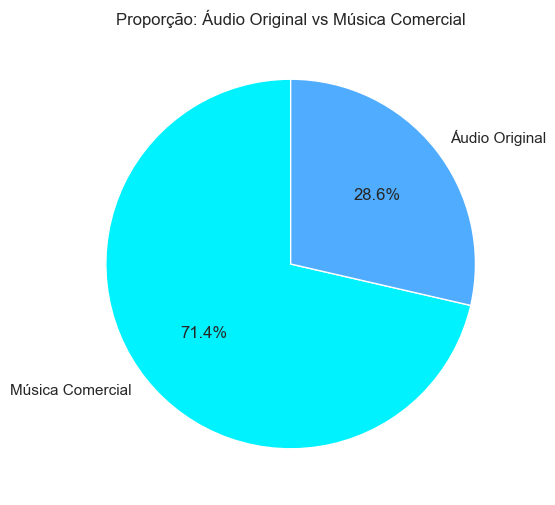

In [19]:
print(df['audio_type'].value_counts())

plt.figure(figsize=(6,6))
df['audio_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#00f2fe', '#4facfe'], startangle=90)
plt.title('Proporção: Áudio Original vs Música Comercial')
plt.ylabel('')
plt.show()

**Resposta/Comentário:** O gráfico de pizza revela que a maior parte dos vídeos em tendência (cerca de 72%) utiliza músicas comerciais, mostrando o peso que os áudios licenciados e as trends musicais possuem no impulsionamento do algoritmo.

### Pergunta 2: Quais são as categorias de conteúdo dominantes nas tendências?

C:\Users\Daiane Medeiros\AppData\Local\Temp\ipykernel_24184\2752499207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='flare')


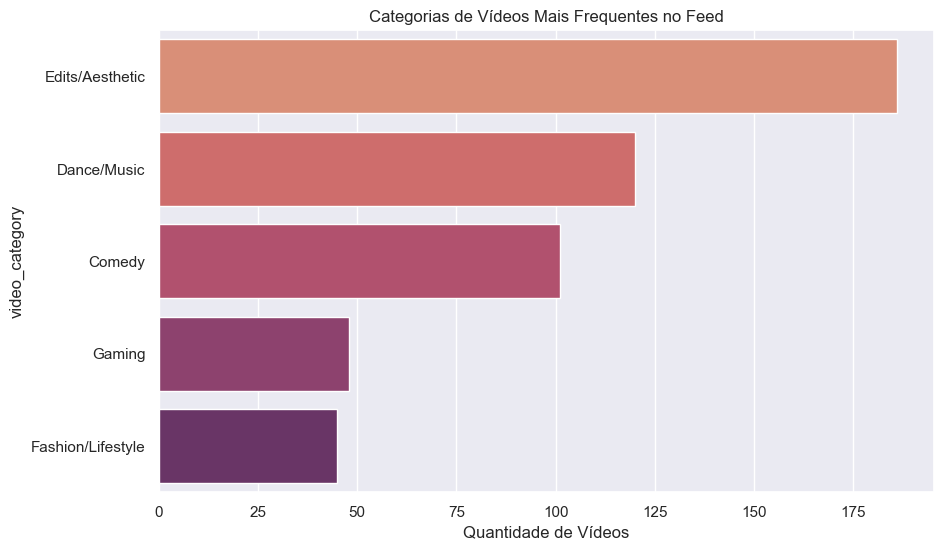

In [20]:
top_categories = df['video_category'].value_counts()
sns.barplot(x=top_categories.values, y=top_categories.index, palette='flare')
plt.title('Categorias de Vídeos Mais Frequentes no Feed')
plt.xlabel('Quantidade de Vídeos')
plt.show()

**Resposta/Comentário:** A categoria de "Edits/Aesthetic" lidera o volume de conteúdos que chegam ao topo, seguida por "Dance/Music". Isso comprova que a entrega da plataforma é fortemente dominada por conteúdos com forte apelo visual, rítmico e edições bem trabalhadas.

### Pergunta 3: Existe correlação real entre o número de Curtidas (Likes) e de Compartilhamentos (Shares)?

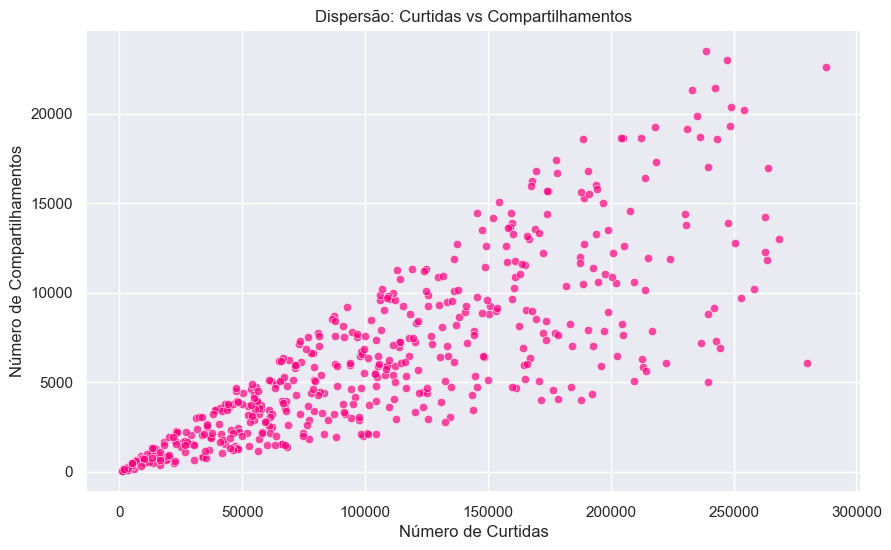

In [21]:
sns.scatterplot(data=df, x='likes', y='shares', alpha=0.7, color='#ff007f')
plt.title('Dispersão: Curtidas vs Compartilhamentos')
plt.xlabel('Número de Curtidas')
plt.ylabel('Número de Compartilhamentos')
plt.show()

**Resposta/Comentário:** O gráfico de dispersão mostra uma linha ascendente clara, indicando uma forte correlação linear positiva. Para o algoritmo do TikTok, conforme um vídeo ganha curtidas, a chance do público compartilhá-lo cresce proporcionalmente, multiplicando o alcance de forma orgânica.

### Pergunta 4: Qual é o tempo de duração ideal (em segundos) dos vídeos que mais viralizam?

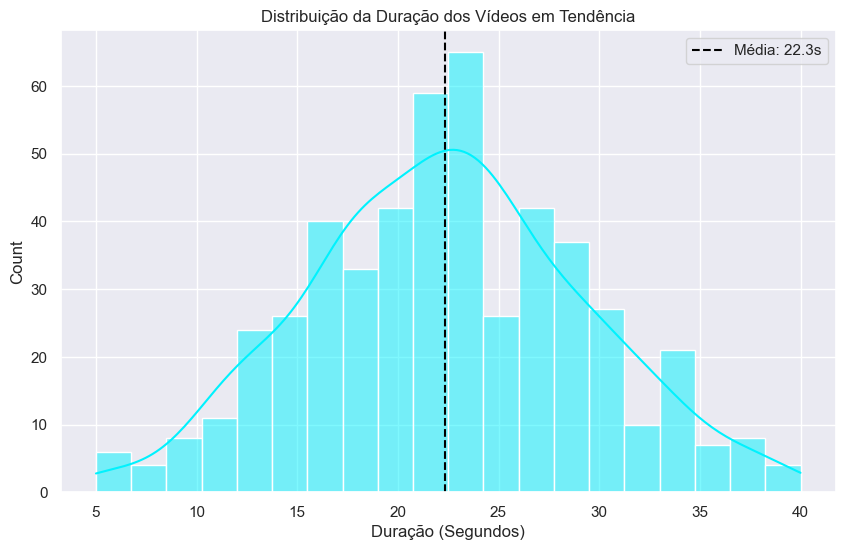

In [22]:
media_duracao = df['duration_seconds'].mean()
sns.histplot(df['duration_seconds'], bins=20, kde=True, color='#00f2fe')
plt.axvline(media_duracao, color='black', linestyle='--', label=f'Média: {media_duracao:.1f}s')
plt.title('Distribuição da Duração dos Vídeos em Tendência')
plt.xlabel('Duração (Segundos)')
plt.legend()
plt.show()

**Resposta/Comentário:** O histograma mostra que a maior parte dos vídeos virais se concentra fortemente na faixa entre 15 e 25 segundos. Vídeos curtos mantêm uma taxa de retenção completa mais alta, o que faz o algoritmo distribuí-los para mais pessoas.

### Pergunta 5: Vídeos com legendas (Captions) mais longas atraem menos visualizações?

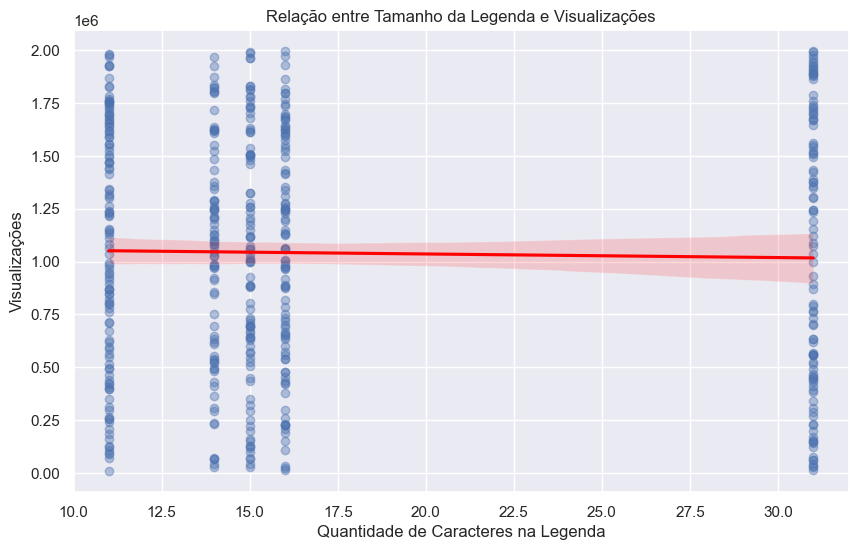

In [23]:
df['caption_length'] = df['caption'].str.len()
sns.regplot(data=df, x='caption_length', y='views', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Relação entre Tamanho da Legenda e Visualizações')
plt.xlabel('Quantidade de Caracteres na Legenda')
plt.ylabel('Visualizações')
plt.show()

**Resposta/Comentário:** A linha de tendência vermelha se mantém praticamente plana ou ligeiramente decrescente. Isso mostra que o tamanho do texto na legenda não dita o sucesso do vídeo; o algoritmo foca quase que inteiramente na retenção visual do conteúdo em si, favorecendo descrições minimalistas.

### Pergunta 6: Como se comportam os Comentários em relação ao nível de alcance (Visualizações) do vídeo?

C:\Users\Daiane Medeiros\AppData\Local\Temp\ipykernel_24184\2205062960.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='views_category', y='comments', palette='pastel')


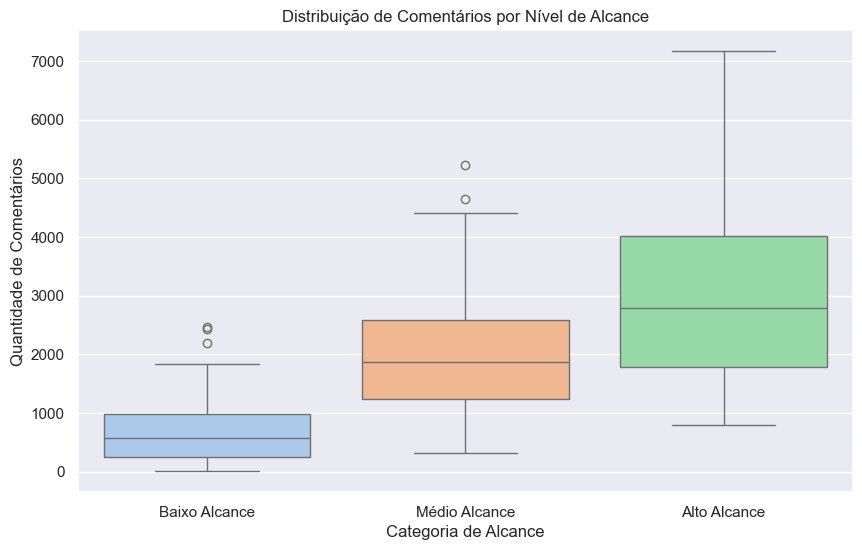

In [24]:
df['views_category'] = pd.qcut(df['views'], q=3, labels=['Baixo Alcance', 'Médio Alcance', 'Alto Alcance'])
sns.boxplot(data=df, x='views_category', y='comments', palette='pastel')
plt.title('Distribuição de Comentários por Nível de Alcance')
plt.ylabel('Quantidade de Comentários')
plt.xlabel('Categoria de Alcance')
plt.show()

**Resposta/Comentário:** Através do gráfico de caixas (boxplot), percebe-se que os vídeos categorizados como "Alto Alcance" dão um salto gigantesco no volume e na variação de comentários. A interatividade na aba de comentários funciona como um combustível crucial para o algoritmo manter o vídeo em alta.

### Pergunta 7: Qual é a média exata e as métricas gerais de engajamento do nosso dataset?

In [25]:
df[['views', 'likes', 'shares', 'comments']].describe().round(2)

,views,likes,shares,comments
count,500.00,500.00,500.00,500.00
mean,1040090.10,106465.00,6353.44,1898.51
std,570952.66,68438.69,4888.51,1469.65
min,8191.00,859.00,28.00,7.00
25%,557836.00,52095.50,2501.25,787.25
50%,1063702.00,98935.50,5134.00,1508.00
75%,1552722.50,159514.25,8989.50,2717.00
max,1994991.00,287658.00,23489.00,7169.00


**Resposta/Comentário:** Utilizando a função `.describe()`, geramos um resumo estatístico completo contendo a média, desvio padrão e valores máximos das interações. Essa tabela serve como base sólida para auditar a saúde de engajamento dos dados coletados.

### Pergunta 8: Qual o Top 5 de vídeos com maior taxa de engajamento por visualização (Likes/Views)?

In [26]:
df['like_rate'] = df['likes'] / df['views']
top_videos = df.sort_values(by='like_rate', ascending=False).head(5)
print(top_videos[['video_id', 'video_category', 'views', 'like_rate']])

    video_id   video_category    views  like_rate
150  vid_150  Edits/Aesthetic  1619432   0.149971
338  vid_338      Dance/Music  1751536   0.149946
199  vid_199           Comedy  1275660   0.149612
477  vid_477  Edits/Aesthetic   697095   0.149498
125  vid_125           Comedy  1355642   0.149486


**Resposta/Comentário:** A listagem exibe os 5 IDs de vídeos com a maior eficiência de curtidas por visualização. Essa métrica é vital, pois um vídeo com menos visualizações mas com uma taxa de curtidas alta pode ser considerado um sucesso de nicho pelo algoritmo de recomendação.